<a href="https://colab.research.google.com/github/ndenizkoroglu/-automation-test-repo/blob/main/Olist_Teslim_Suresi_Analizi_ipynb_Deniz_K%C3%B6ro%C4%9Flu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import zipfile, os

zip_path = "/content/drive/MyDrive/Colab Notebooks/data.zip"
extract_path = "/content/drive/MyDrive/Colab Notebooks/olist"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

os.listdir(extract_path)



['data', '__MACOSX']

In [3]:
data_path = "/content/drive/MyDrive/Colab Notebooks/olist/data"
os.listdir(data_path)


['olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_sellers_dataset.gsheet',
 'olist_products_dataset.gsheet',
 'olist_orders_dataset.gsheet',
 'olist_order_reviews_dataset.gsheet',
 'olist_order_payments_dataset.gsheet',
 'olist_sellers_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_customers_dataset.csv',
 'olist_products_dataset.csv']

In [4]:
import pandas as pd

orders = pd.read_csv(
    f"{data_path}/olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

order_items = pd.read_csv(f"{data_path}/olist_order_items_dataset.csv")
payments = pd.read_csv(f"{data_path}/olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{data_path}/olist_order_reviews_dataset.csv")
products = pd.read_csv(f"{data_path}/olist_products_dataset.csv")
customers = pd.read_csv(f"{data_path}/olist_customers_dataset.csv")


*Analizde kullanılacak veri setleri pandas ile içe aktarılmış ve tarih değişkenleri uygun formata dönüştürülmüştür.*

In [5]:
orders["order_status"].value_counts(normalize=True)


,proportion
order_status,
delivered,0.970203
shipped,0.011132
canceled,0.006285
unavailable,0.006124
invoiced,0.003158
processing,0.003027
created,0.000050
approved,0.000020


*Siparişlerin büyük çoğunluğu teslim edilmiş olduğu için analiz teslim edilen siparişler üzerinden devam edilmiştir.*


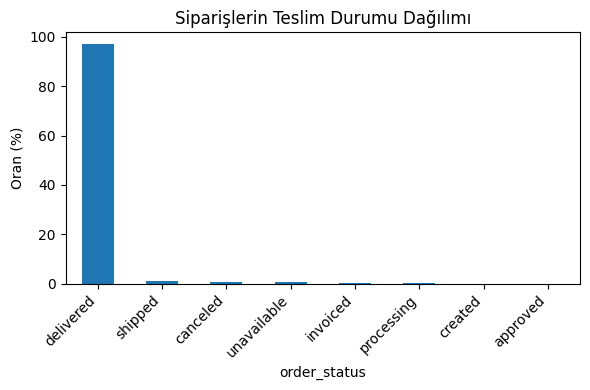

In [6]:
import matplotlib.pyplot as plt

status_counts = (
    orders["order_status"]
    .value_counts(normalize=True)
    .mul(100)  # yüzdeye çevir
)

plt.figure(figsize=(6,4))
status_counts.plot(kind="bar")
plt.ylabel("Oran (%)")
plt.title("Siparişlerin Teslim Durumu Dağılımı")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


*Sipariş durumlarının dağılımı daha net görülebilmesi için çubuk grafik ile görselleştirilmiştir. Grafik incelendiğinde siparişlerin büyük çoğunluğunun “delivered” olduğu açıkça görülmektedir.*

In [7]:
orders_delivered = orders[orders["order_status"] == "delivered"].copy()


*Teslimat süresi hesaplanabilmesi için gerçek teslim tarihi gerekmektedir. Bu nedenle analiz yalnızca “delivered” durumundaki siparişler ile sınırlandırılmıştır.*

In [8]:
orders_delivered["delivery_days"] = (
    orders_delivered["order_delivered_customer_date"] -
    orders_delivered["order_purchase_timestamp"]
).dt.days

orders_delivered["delivery_days"].describe()


,delivery_days
count,96470.000000
mean,12.093604
std,9.551380
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


*İstatistiklere göre siparişlerin yarısı yaklaşık 10 gün içinde teslim edilmektedir (medyan). Ortalama teslim süresi yaklaşık 12 gündür. Ortalama değerin medyandan büyük olması dağılımın sağa çarpık olduğunu göstermektedir. Maksimum teslim süresinin 200 günün üzerinde olması, az sayıda uç değer bulunduğuna işaret etmektedir.*

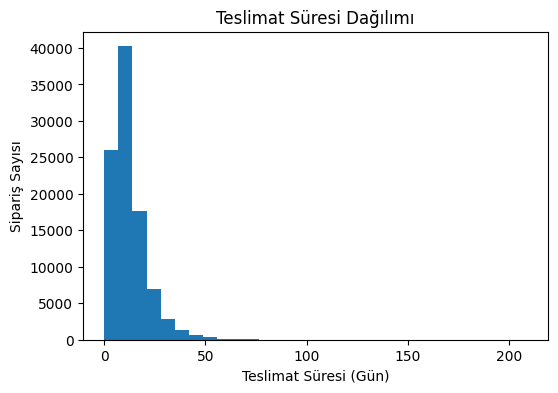

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(orders_delivered["delivery_days"], bins=30)
plt.xlabel("Teslimat Süresi (Gün)")
plt.ylabel("Sipariş Sayısı")
plt.title("Teslimat Süresi Dağılımı")
plt.show()


*Teslimat sürelerinin dağılımı incelendiğinde siparişlerin büyük bir kısmının 5–15 gün aralığında müşterilere ulaştığı görülmektedir. Dağılım sağa çarpık olup, az sayıda siparişte oldukça uzun teslim süreleri gözlemlenmektedir.*

In [10]:
orders_delivered["delivery_delay"] = (
    orders_delivered["order_delivered_customer_date"] -
    orders_delivered["order_estimated_delivery_date"]
).dt.days


In [11]:
orders_delivered.columns


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_days', 'delivery_delay'],
      dtype='object')

*Teslimat gecikmesi, tahmini teslim tarihi ile gerçek teslim tarihi arasındaki fark olarak hesaplanmıştır. Pozitif değerler teslimatın geciktiğini, negatif değerler ise tahmini tarihten erken teslim edildiğini göstermektedir.*



In [12]:
(
    (orders_delivered["delivery_delay"] > 0)
    .value_counts(normalize=True)
    .rename({False: "Zamanında / Erken", True: "Gecikmiş"})
    * 100
).round(2)


,proportion
delivery_delay,
Zamanında / Erken,93.23
Gecikmiş,6.77


*Siparişlerin yaklaşık %93’ü zamanında veya erken teslim edilirken, %7’sinde gecikme yaşanmıştır.*


In [13]:
orders_reviews = orders_delivered.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)


*Müşteri memnuniyetini analiz edebilmek için siparişler ile yorum puanları birleştirilmiştir.*


In [14]:
orders_reviews = orders_reviews.dropna(subset=["review_score"])


*Yorum puanı bulunmayan siparişler, memnuniyet analizlerinde analiz dışı bırakılmıştır.*



In [15]:
orders_reviews["gecikme_durumu"] = orders_reviews["delivery_delay"] > 0

orders_reviews.groupby("gecikme_durumu")["review_score"].mean().rename({
    False: "Zamanında / Erken",
    True: "Gecikmiş"
})


,review_score
gecikme_durumu,
Zamanında / Erken,4.289999
Gecikmiş,2.271025


*Gecikmiş grubun ortalamasının daha düşük olduğu görülmektedir.*

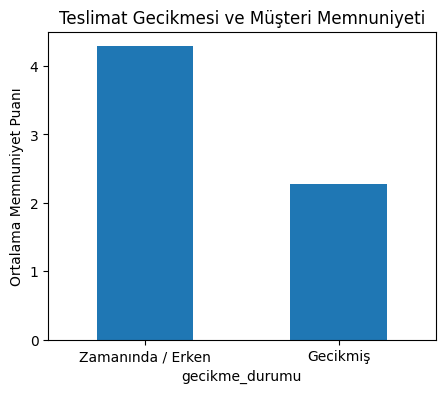

In [16]:
import matplotlib.pyplot as plt

mean_scores = (
    orders_reviews
    .groupby("gecikme_durumu")["review_score"]
    .mean()
    .rename({False: "Zamanında / Erken", True: "Gecikmiş"})
)

plt.figure(figsize=(5,4))
mean_scores.plot(kind="bar")
plt.ylabel("Ortalama Memnuniyet Puanı")
plt.title("Teslimat Gecikmesi ve Müşteri Memnuniyeti")
plt.xticks(rotation=0)
plt.show()


In [17]:
from scipy.stats import ttest_ind

on_time = orders_reviews.loc[
    orders_reviews["gecikme_durumu"] == False, "review_score"
]

delayed = orders_reviews.loc[
    orders_reviews["gecikme_durumu"] == True, "review_score"
]

ttest_ind(on_time, delayed, equal_var=False)


TtestResult(statistic=np.float64(100.96653430713094), pvalue=np.float64(0.0), df=np.float64(6905.583486777538))


H0: Teslimat gecikmesi müşteri memnuniyetini etkilemez.  
H1: Teslimat gecikmesi müşteri memnuniyetini etkiler.

Yapılan t-testi sonucunda iki grup arasında istatistiksel olarak anlamlı bir fark bulunmuştur (p < 0.05).


In [18]:
orders_reviews_items = (
    orders_reviews
    .merge(order_items, on="order_id", how="inner")
    .merge(products, on="product_id", how="inner")
)


Yorum puanlarını ürün kategorileriyle birlikte inceleyebilmek için sipariş yorumları, sipariş detayları ve ürün bilgileri birleştirilmiştir. Böylece her bir müşteri değerlendirmesi ilgili ürün kategorisiyle eşleştirilmiştir.

In [19]:
orders_reviews_items = orders_reviews_items.dropna(subset=["product_category_name"])


Ürün kategorisi bilgisi olmayan siparişler analizde kullanılamayacağı için bu gözlemler veri setinden çıkarılmıştır.

In [20]:
top_categories = (
    orders_reviews_items["product_category_name"]
    .value_counts()
    .head(10)
    .index
)

category_scores = (
    orders_reviews_items[
        orders_reviews_items["product_category_name"].isin(top_categories)
    ]
    .groupby("product_category_name")["review_score"]
    .mean()
    .sort_values(ascending=False)
)


Çok az sayıda siparişe sahip kategoriler sonuçları yanıltabileceği için, analize en fazla sipariş alan ilk 10 ürün kategorisi dahil edilmiştir.

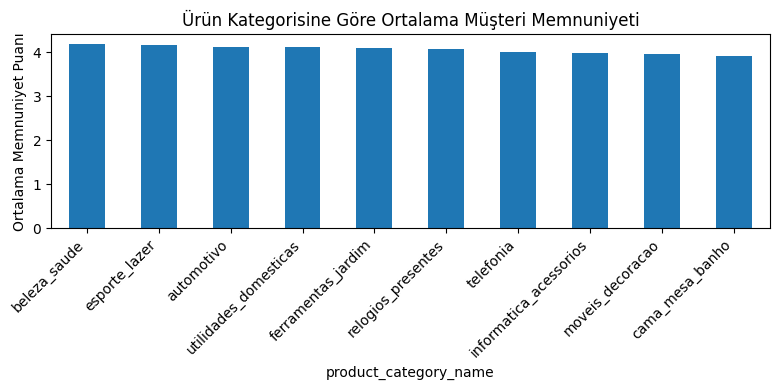

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
category_scores.plot(kind="bar")
plt.ylabel("Ortalama Memnuniyet Puanı")
plt.title("Ürün Kategorisine Göre Ortalama Müşteri Memnuniyeti")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



Puanlar birbirine çok yakın olduğu için farkları daha net görebilmek amacıyla ikinci bir tablo oluşturulmuştur.
Bu tablo sayesinde hangi kategorinin daha yüksek veya daha düşük puan aldığı sayısal olarak daha açık şekilde görülmektedir.

In [22]:
category_scores.round(3)


,review_score
product_category_name,
beleza_saude,4.191
esporte_lazer,4.166
automotivo,4.116
utilidades_domesticas,4.108
ferramentas_jardim,4.081
relogios_presentes,4.072
telefonia,3.995
informatica_acessorios,3.985
moveis_decoracao,3.950


En yüksek ortalama memnuniyet beleza_saude kategorisinde, en düşük ise cama_mesa_banho kategorisinde gözlemlenmiştir.